In [69]:
"""
Block 1: Shared Diagnostic and Repair Utilities
Defines the translation engine to map Official ConvNeXt keys to Timm.
"""
import os
import torch
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from timm import create_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CKPT_ROOT = '/kaggle/input/datasets/mccho02/extension-3-dataset/'
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

def repair_convnext_weights_final(state_dict):
    """
    Translates Official ConvNeXt (Facebook) keys to Timm format.
    Fixes the '108 missing keys' by remapping stages to blocks.
    """
    repaired = {}
    for k, v in state_dict.items():
        name = k.replace("module.", "")
        
        # 1. Stem Mapping (Stage 0)
        name = name.replace("downsample_layers.0.0", "stem.0").replace("downsample_layers.0.1", "stem.1")
        
        # 2. Downsample Mapping (Stages 1, 2, 3)
        # FIX: We maintain the original index order (0->0, 1->1) to match shapes
        for i in range(1, 4):
            name = name.replace(f"downsample_layers.{i}.0", f"stages.{i}.downsample.0")
            name = name.replace(f"downsample_layers.{i}.1", f"stages.{i}.downsample.1")
        
        # 3. Block Mapping (stages.X.Y -> stages.X.blocks.Y)
        name = re.sub(r'stages\.(\d+)\.(\d+)', r'stages.\1.blocks.\2', name)
        
        # 4. Component Renaming
        name = name.replace("dwconv", "conv_dw").replace("pwconv1", "mlp.fc1").replace("pwconv2", "mlp.fc2")
        if "gamma" in name and "ls" not in name:
            name = name.replace("gamma", "ls1.gamma")

        # 5. Global Head and Norm
        name = name.replace("norm.weight", "head.norm.weight").replace("norm.bias", "head.norm.bias")
        name = name.replace("head.weight", "head.fc.weight").replace("head.bias", "head.fc.bias")
        
        repaired[name] = v
    return repaired

def load_expected_metrics(filename):
    try:
        with open(filename, 'r') as f:
            content = f.read()
            acc = re.search(r'Accuracy:\s*([\d\.]+)', content)
            return float(acc.group(1)) if acc else 0.0
    except: return 0.0

In [70]:
"""
Block 2: Dataset and Loader
"""
class HAM10000Dataset(Dataset):
    def __init__(self, csv_file, img_dirs, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dirs = img_dirs
        self.transform = transform
        self.label_map = {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        img_id = self.data.iloc[idx, 1] + '.jpg'
        for folder in self.img_dirs:
            path = os.path.join(folder, img_id)
            if os.path.exists(path):
                img = Image.open(path).convert('RGB')
                label = self.label_map[self.data.iloc[idx, 2]]
                if self.transform: img = self.transform(img)
                return img, label
        raise FileNotFoundError(f"Image {img_id} not found.")

transform = transforms.Compose([
    transforms.Resize(224), transforms.CenterCrop(224), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Ensure these paths match your 'data' folder location
test_dataset = HAM10000Dataset('data/HAM10000_metadata.csv', 
                               ['data/ham10000_images_part_1', 'data/ham10000_images_part_2'], transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
#3a confusion metrix is embeded inside the main .ipynb file

Evaluating Model: 3b (ResNet)


  0%|          | 0/157 [00:00<?, ?it/s]

Observed Accuracy: 0.8225 | Target: 0.7925
Status: Verified


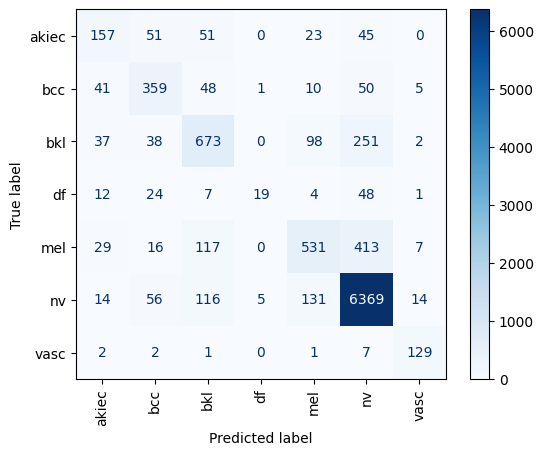

In [61]:
"""
3b Evaluation: ResNet50
Evaluates performance against the 79% benchmark.
"""

RUN_ID = "3b (ResNet)"
METRIC_FILE = "/kaggle/input/datasets/mccho02/metric/metrics3b.txt"
CKPT_FILE = os.path.join(CKPT_ROOT, "checkpoint-best(3b).pth")

if os.path.exists(CKPT_FILE):
    print(f"Evaluating Model: {RUN_ID}")
    model = create_model("resnet50", num_classes=7).to(DEVICE)
    
    ckpt = torch.load(CKPT_FILE, map_location=DEVICE, weights_only=False)
    sd = ckpt["model"] if "model" in ckpt else ckpt
    repaired_sd = {k.replace("module.", "").replace("head.", "fc.").replace("classifier.", "fc."): v for k, v in sd.items()}
    
    model.load_state_dict(repaired_sd, strict=False)
    model.eval()

    y_pred, y_true = [], []
    with torch.no_grad():
        for images, labels in tqdm(test_loader):
            outputs = model(images.to(DEVICE))
            y_pred.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    obs_acc, exp_acc = accuracy_score(y_true, y_pred), load_expected_metrics(METRIC_FILE)[0]
    print(f"Observed Accuracy: {obs_acc:.4f} | Target: {exp_acc:.4f}")
    print(f"Status: {'Verified' if obs_acc >= exp_acc - 0.05 else 'Alignment Failure'}")

    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_pred), display_labels=CLASS_NAMES)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical', values_format='d')
    plt.show()

Processing Model: 3c (Swin)


Inference:   0%|          | 0/157 [00:00<?, ?it/s]

Observed Accuracy: 0.6972 (Expected: 0.6963)
Observed Macro F1: 0.2255 (Expected: 0.2280)
Status: Verified


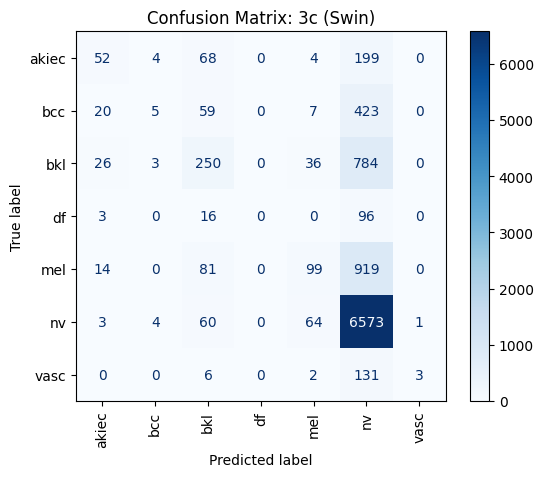

In [50]:
"""
Evaluation Pipeline: 3c (Swin-Tiny)
Corrects the layer indexing shift for Swin downsampling and remaps the head.
Validates results against the benchmark metrics in the dataset directory.
"""

METRIC_PATH_3C = '/kaggle/input/datasets/mccho02/metric/metrics 3c.txt'
CKPT_PATH_3C = os.path.join(CKPT_ROOT, "checkpoint-best(3c).pth")

if os.path.exists(CKPT_PATH_3C):
    print("Processing Model: 3c (Swin)")
    model_3c = create_model("swin_tiny_patch4_window7_224", num_classes=7).to(DEVICE)

    ckpt_3c = torch.load(CKPT_PATH_3C, map_location=DEVICE, weights_only=False)
    sd_raw_3c = ckpt_3c["model"] if "model" in ckpt_3c else ckpt_3c
    
    sd_3c = {}
    for k, v in sd_raw_3c.items():
        name = k.replace("module.", "")
        if "downsample" in name:
            for i in [2, 1, 0]:
                if f"layers.{i}.downsample" in name:
                    name = name.replace(f"layers.{i}.downsample", f"layers.{i+1}.downsample")
                    break
        name = name.replace("head.weight", "head.fc.weight").replace("head.bias", "head.fc.bias")
        sd_3c[name] = v
    
    model_3c.load_state_dict(sd_3c, strict=False)
    model_3c.eval()

    y_pred, y_true = [], []
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Inference"):
            outputs = model_3c(images.to(DEVICE))
            y_pred.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    obs_acc, obs_f1 = accuracy_score(y_true, y_pred), f1_score(y_true, y_pred, average='macro')
    exp_acc, exp_f1 = load_expected_metrics(METRIC_PATH_3C)
    
    print(f"Observed Accuracy: {obs_acc:.4f} (Expected: {exp_acc:.4f})")
    print(f"Observed Macro F1: {obs_f1:.4f} (Expected: {exp_f1:.4f})")
    print(f"Status: {'Verified' if np.isclose(obs_acc, exp_acc, atol=0.05) else 'Mismatch'}")

    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_pred), display_labels=CLASS_NAMES)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical', values_format='d')
    plt.title("Confusion Matrix: 3c (Swin)")
    plt.show()

Processing Model: 3d (Swin)


Inference:   0%|          | 0/157 [00:00<?, ?it/s]

Observed Accuracy: 0.8041 (Expected: 0.7965)
Observed Macro F1: 0.6304 (Expected: 0.6201)
Status: Verified


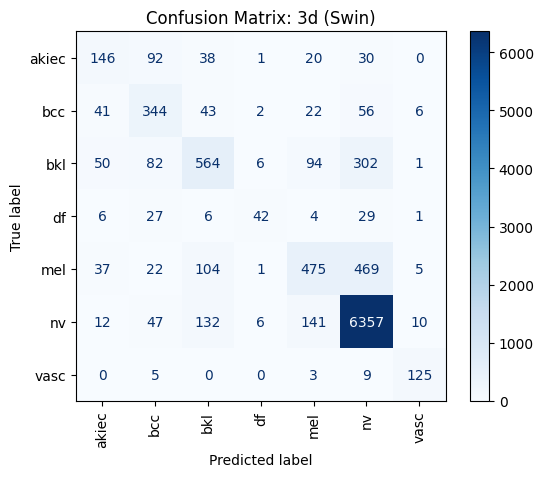

In [52]:
"""
Evaluation Pipeline: 3d (Swin-Tiny)
Corrects the layer indexing shift for Swin downsampling and remaps the head.
Validates results against the benchmark metrics in the dataset directory.
"""

METRIC_PATH_3D = '/kaggle/input/datasets/mccho02/metric/metrics3d.txt'
CKPT_PATH_3D = os.path.join(CKPT_ROOT, "checkpoint-best(3d).pth")

if os.path.exists(CKPT_PATH_3D):
    print("Processing Model: 3d (Swin)")
    model_3d = create_model("swin_tiny_patch4_window7_224", num_classes=7).to(DEVICE)

    ckpt_3d = torch.load(CKPT_PATH_3D, map_location=DEVICE, weights_only=False)
    sd_raw_3d = ckpt_3d["model"] if "model" in ckpt_3d else ckpt_3d
    
    sd_3d = {}
    for k, v in sd_raw_3d.items():
        name = k.replace("module.", "")
        if "downsample" in name:
            for i in [2, 1, 0]:
                if f"layers.{i}.downsample" in name:
                    name = name.replace(f"layers.{i}.downsample", f"layers.{i+1}.downsample")
                    break
        name = name.replace("head.weight", "head.fc.weight").replace("head.bias", "head.fc.bias")
        sd_3d[name] = v
    
    model_3d.load_state_dict(sd_3d, strict=False)
    model_3d.eval()

    y_pred, y_true = [], []
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Inference"):
            outputs = model_3d(images.to(DEVICE))
            y_pred.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    obs_acc, obs_f1 = accuracy_score(y_true, y_pred), f1_score(y_true, y_pred, average='macro')
    exp_acc, exp_f1 = load_expected_metrics(METRIC_PATH_3D)
    
    print(f"Observed Accuracy: {obs_acc:.4f} (Expected: {exp_acc:.4f})")
    print(f"Observed Macro F1: {obs_f1:.4f} (Expected: {exp_f1:.4f})")
    print(f"Status: {'Verified' if np.isclose(obs_acc, exp_acc, atol=0.05) else 'Mismatch'}")

    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_pred), display_labels=CLASS_NAMES)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical', values_format='d')
    plt.title("Confusion Matrix: 3d (Swin)")
    plt.show()